# Обучение без учителя

Кольчурин Андрей Николавеич

студент физико-математического института,

направления радиофизика,

группы ФМ/О РФЗ-1-2022 НБ

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

In [4]:
# Загрузка данных
df = pd.read_csv('cirrhosis1.csv')

In [5]:
print(f"Размер датасета: {df.shape}")

Размер датасета: (312, 20)


In [7]:

df.head()

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,2.0,0.0,21464,0.0,1.0,1.0,1.0,2.0,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,0.0,0.0,20617,0.0,0.0,1.0,1.0,0.0,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,2.0,0.0,25594,1.0,0.0,0.0,0.0,1.0,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,2.0,0.0,19994,0.0,0.0,1.0,1.0,1.0,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,1.0,1.0,13918,0.0,0.0,1.0,1.0,0.0,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 312 entries, 0 to 311
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             312 non-null    int64  
 1   N_Days         312 non-null    int64  
 2   Status         312 non-null    float64
 3   Drug           312 non-null    float64
 4   Age            312 non-null    int64  
 5   Sex            312 non-null    float64
 6   Ascites        312 non-null    float64
 7   Hepatomegaly   312 non-null    float64
 8   Spiders        312 non-null    float64
 9   Edema          312 non-null    float64
 10  Bilirubin      312 non-null    float64
 11  Cholesterol    312 non-null    float64
 12  Albumin        312 non-null    float64
 13  Copper         312 non-null    float64
 14  Alk_Phos       312 non-null    float64
 15  SGOT           312 non-null    float64
 16  Tryglicerides  312 non-null    float64
 17  Platelets      312 non-null    float64
 18  Prothrombi

In [9]:
df.describe()

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
count,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000
mean,156.500000,2006.362179,0.862179,0.493590,18269.442308,0.115385,0.076923,0.512821,0.288462,0.221154,3.256090,364.125000,3.520000,97.490385,1982.655769,122.556346,123.096154,261.871795,10.725641,3.032051
std,90.210864,1123.280843,0.960764,0.500762,3864.805407,0.319999,0.266897,0.500639,0.453775,0.549014,4.530315,221.923027,0.419892,85.360932,2140.388824,56.699525,62.122820,94.993533,1.004323,0.877880
min,1.000000,41.000000,0.000000,0.000000,9598.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.300000,120.000000,1.960000,4.000000,289.000000,26.350000,33.000000,62.000000,9.000000,1.000000
25%,78.750000,1191.000000,0.000000,0.000000,15427.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.800000,255.750000,3.310000,41.750000,871.500000,80.600000,87.000000,200.000000,10.000000,2.000000
50%,156.500000,1839.500000,0.000000,0.000000,18187.500000,0.000000,0.000000,1.000000,0.000000,0.000000,1.350000,309.500000,3.550000,73.000000,1259.000000,114.700000,108.000000,257.000000,10.600000,3.000000
75%,234.250000,2697.250000,2.000000,1.000000,20715.000000,0.000000,0.000000,1.000000,1.000000,0.000000,3.425000,392.250000,3.800000,123.000000,1980.000000,151.900000,145.250000,322.000000,11.100000,4.000000
max,312.000000,4556.000000,2.000000,1.000000,28650.000000,1.000000,1.000000,1.000000,1.000000,2.000000,28.000000,1775.000000,4.640000,588.000000,13862.400000,457.250000,598.000000,563.000000,17.100000,4.000000


In [10]:
print("Пропущенные значения:")
print(df.isnull().sum())


Пропущенные значения:
ID               0
N_Days           0
Status           0
Drug             0
Age              0
Sex              0
Ascites          0
Hepatomegaly     0
Spiders          0
Edema            0
Bilirubin        0
Cholesterol      0
Albumin          0
Copper           0
Alk_Phos         0
SGOT             0
Tryglicerides    0
Platelets        0
Prothrombin      0
Stage            0
dtype: int64


In [11]:
if 'ID' in df.columns:
    df = df.drop('ID', axis=1)

In [13]:
# Разделение на числовые и категориальные признаки
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

In [15]:
# Масштабирование данных (критически важно для методов уменьшения размерности)
df_processed = df.copy()
label_encoders = {}
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_processed)
X_scaled_df = pd.DataFrame(X_scaled, columns=df_processed.columns)

# Методы уменьшения размерности


**PCA (Principal Component Analysis)**

PCA — линейный метод, который находит ортогональные направления максимальной дисперсии. Подходит для начального исследования структуры данных, выявления корреляций и визуализации в 2D/3D.

In [16]:
# Применение PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [17]:
pca_full = PCA()
pca_full.fit(X_scaled)
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

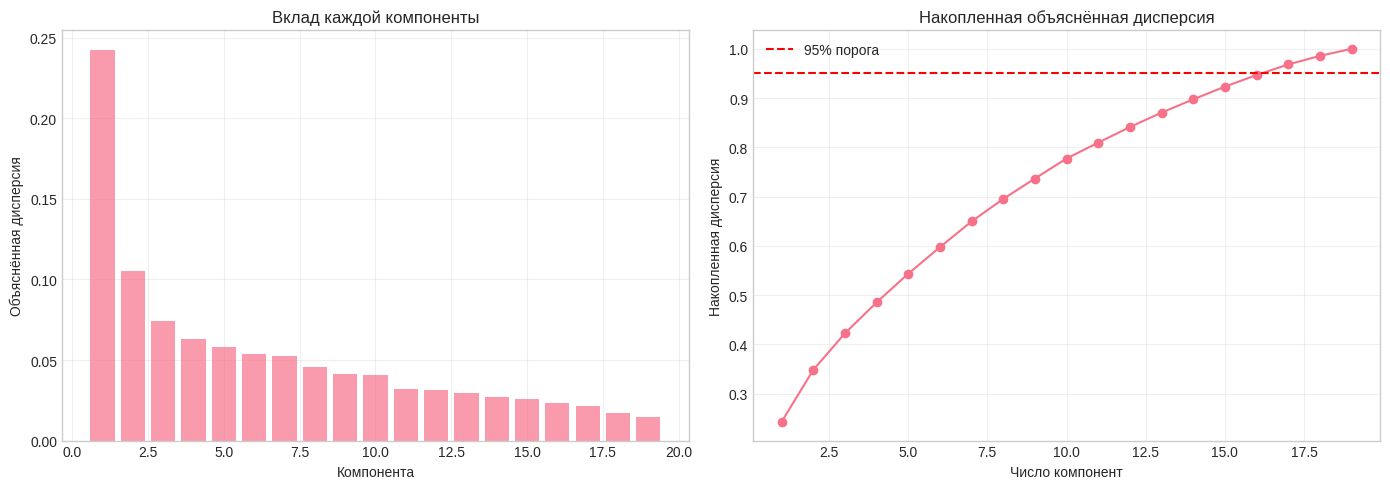

Первые 2 компоненты объясняют: 34.80% дисперсии
Для 95% дисперсии нужно компонент: 17


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, len(explained_variance)+1), explained_variance[:len(explained_variance)], alpha=0.7)
axes[0].set_xlabel('Компонента')
axes[0].set_ylabel('Объяснённая дисперсия')
axes[0].set_title('Вклад каждой компоненты')
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% порога')
axes[1].set_xlabel('Число компонент')
axes[1].set_ylabel('Накопленная дисперсия')
axes[1].set_title('Накопленная объяснённая дисперсия')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Первые 2 компоненты объясняют: {explained_variance[:2].sum()*100:.2f}% дисперсии")
print(f"Для 95% дисперсии нужно компонент: {np.argmax(cumulative_variance >= 0.95) + 1}")

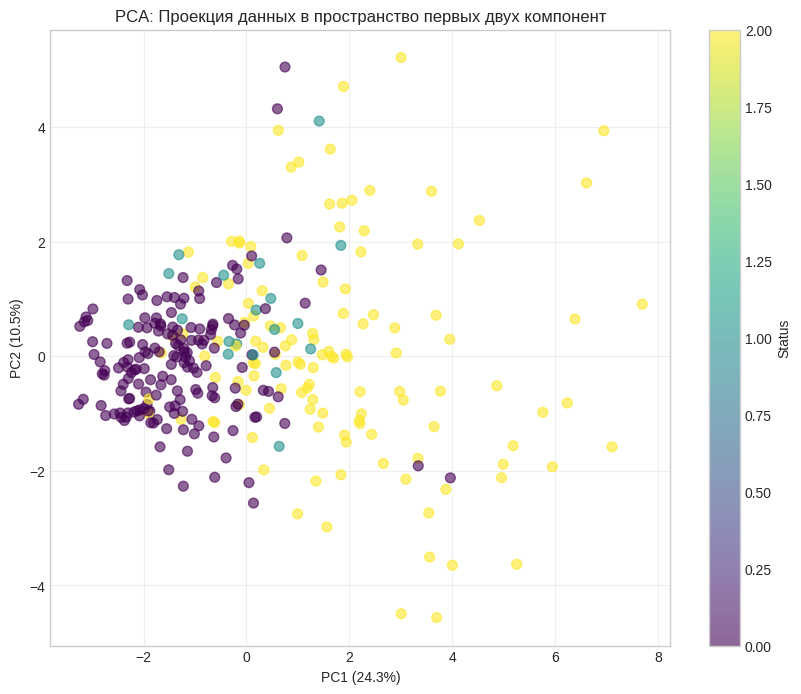

In [19]:
# Визуализация в пространстве первых двух компонент
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                     c=df['Status'] if 'Status' in df.columns else np.zeros(len(df)),
                     cmap='viridis', alpha=0.6, s=50)
plt.xlabel(f'PC1 ({explained_variance[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({explained_variance[1]*100:.1f}%)')
plt.title('PCA: Проекция данных в пространство первых двух компонент')
plt.colorbar(scatter, label='Status' if 'Status' in df.columns else 'Cluster')
plt.grid(True, alpha=0.3)
plt.show()


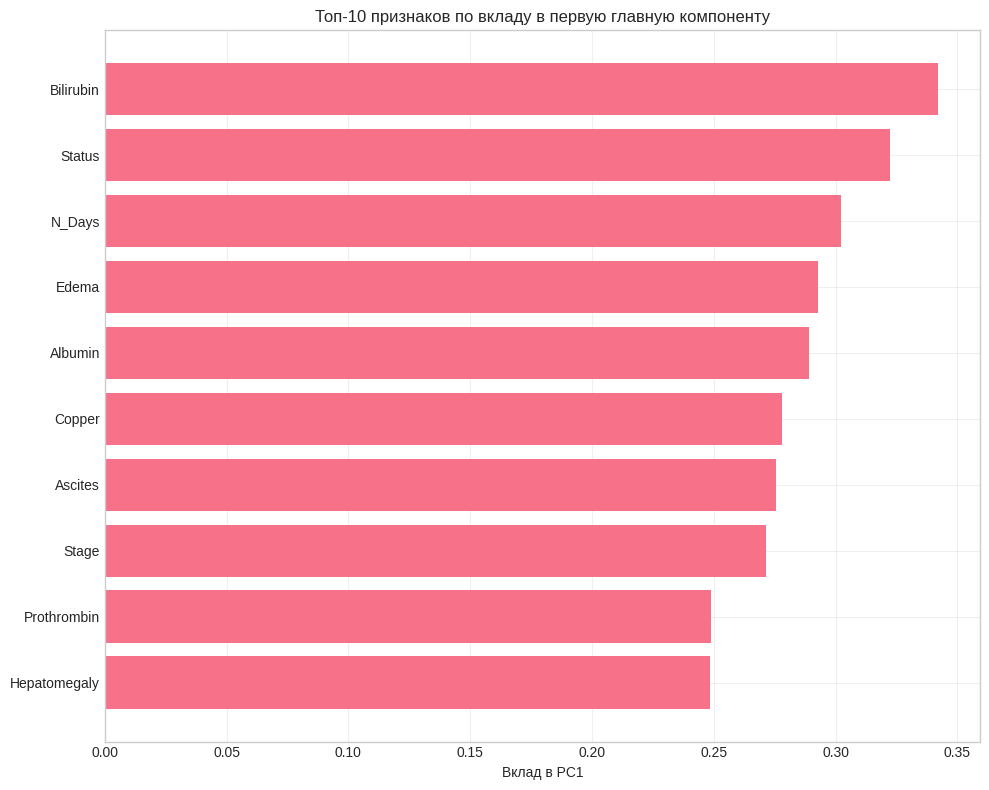

In [20]:
# Анализ вклада признаков в компоненты
pca_components = pd.DataFrame(
    pca_full.components_.T,
    columns=[f'PC{i+1}' for i in range(len(pca_full.components_))],
    index=df_processed.columns
)

plt.figure(figsize=(10, 8))
top_features = pca_components['PC1'].abs().sort_values(ascending=False).head(10)
plt.barh(top_features.index, top_features.values)
plt.xlabel('Вклад в PC1')
plt.title('Топ-10 признаков по вкладу в первую главную компоненту')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**t-SNE**

t-SNE — нелинейный метод, сохраняющий локальные соседства точек. Эффективен для визуализации кластерной структуры, но не сохраняет глобальные расстояния. Требует тщательного подбора гиперпараметров.

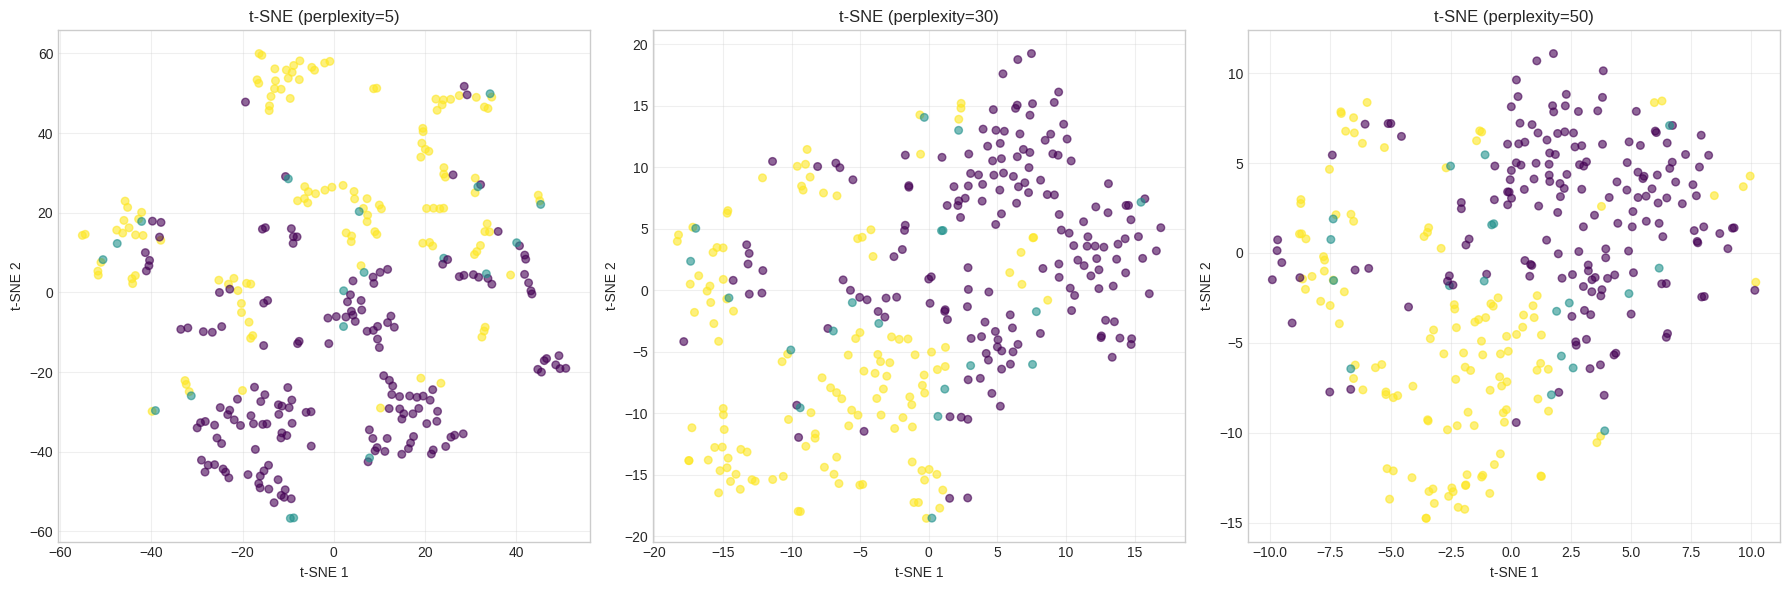

In [21]:
# Применение t-SNE с разными параметрами
perplexity_values = [5, 30, 50]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, perplexity in enumerate(perplexity_values):
    tsne = TSNE(n_components=2, perplexity=perplexity,
                random_state=42, n_iter=1000, learning_rate='auto')
    X_tsne = tsne.fit_transform(X_scaled)

    axes[idx].scatter(X_tsne[:, 0], X_tsne[:, 1],
                     c=df['Status'] if 'Status' in df.columns else np.zeros(len(df)),
                     cmap='viridis', alpha=0.6, s=30)
    axes[idx].set_xlabel('t-SNE 1')
    axes[idx].set_ylabel('t-SNE 2')
    axes[idx].set_title(f't-SNE (perplexity={perplexity})')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



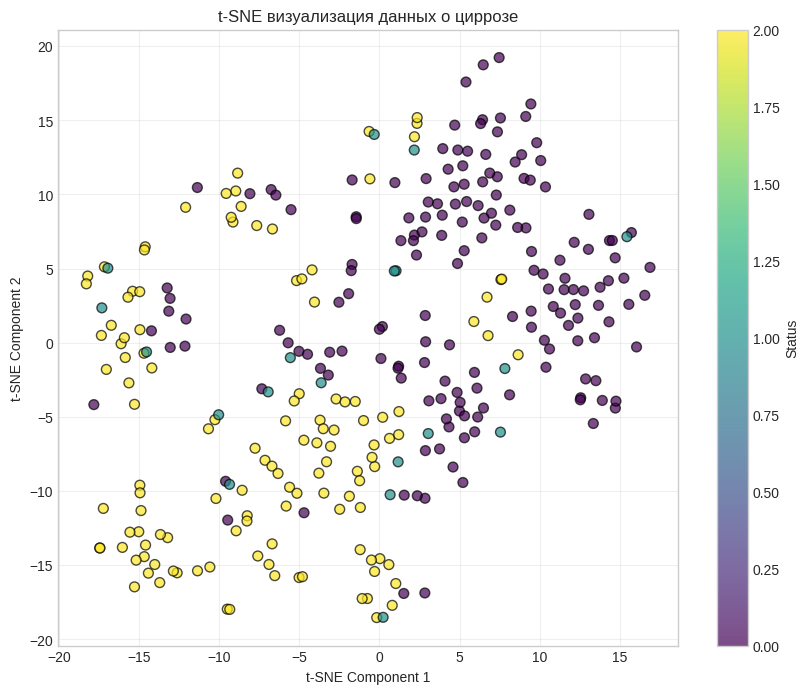

In [22]:
# Оптимальный t-SNE для дальнейшего анализа
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000, learning_rate='auto')
X_tsne_final = tsne.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
plt.scatter(X_tsne_final[:, 0], X_tsne_final[:, 1],
           c=df['Status'] if 'Status' in df.columns else np.zeros(len(df)),
           cmap='viridis', alpha=0.7, s=50, edgecolors='black')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('t-SNE визуализация данных о циррозе')
plt.colorbar(label='Status' if 'Status' in df.columns else 'Cluster')
plt.grid(True, alpha=0.3)
plt.show()

**UMAP**

UMAP — современный нелинейный метод, сохраняющий как локальную, так и глобальную структуру данных. Быстрее t-SNE и лучше масштабируется на большие датасеты.

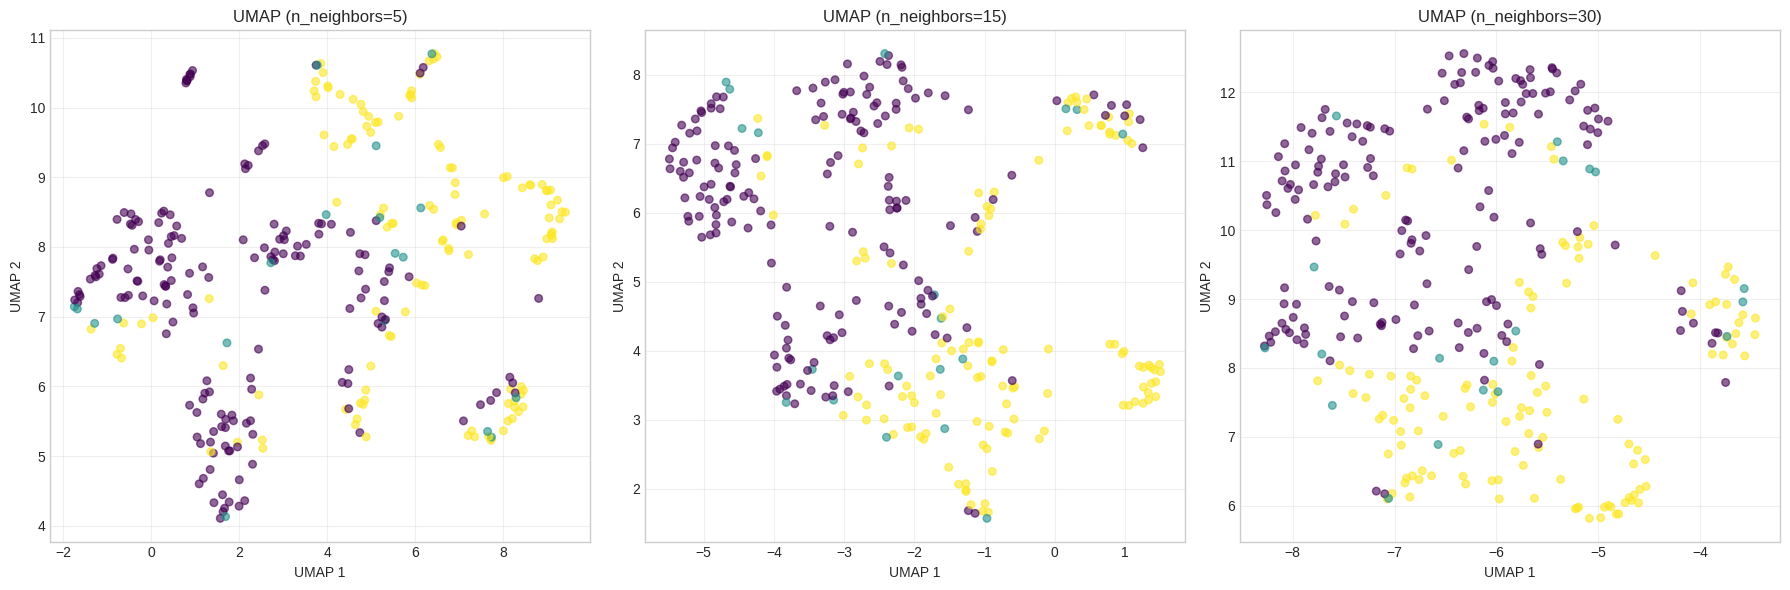

In [23]:
# Применение UMAP с разными параметрами
n_neighbors_values = [5, 15, 30]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, n_neighbors in enumerate(n_neighbors_values):
    umap_model = umap.UMAP(n_components=2, n_neighbors=n_neighbors,
                          min_dist=0.1, random_state=42)
    X_umap = umap_model.fit_transform(X_scaled)

    axes[idx].scatter(X_umap[:, 0], X_umap[:, 1],
                     c=df['Status'] if 'Status' in df.columns else np.zeros(len(df)),
                     cmap='viridis', alpha=0.6, s=30)
    axes[idx].set_xlabel('UMAP 1')
    axes[idx].set_ylabel('UMAP 2')
    axes[idx].set_title(f'UMAP (n_neighbors={n_neighbors})')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



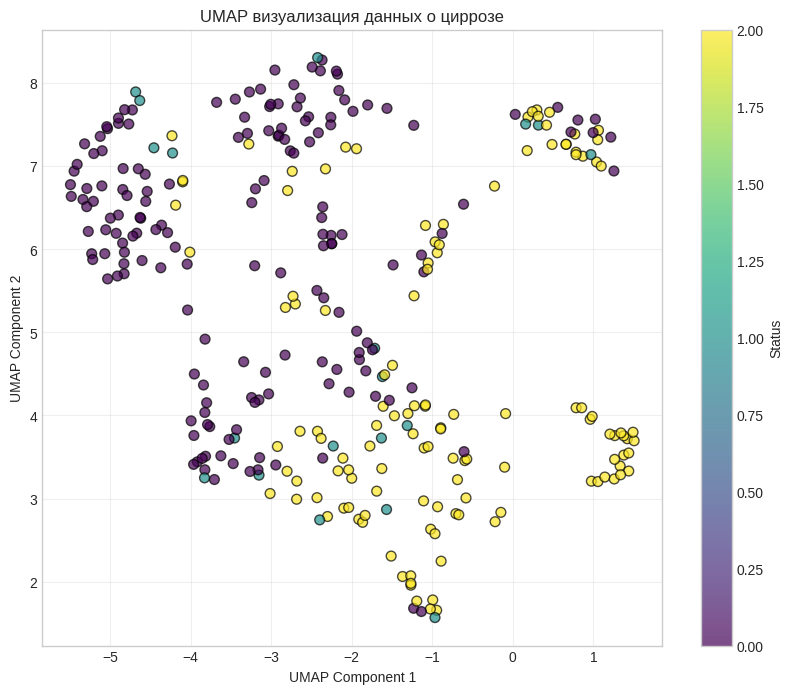

In [24]:
# Оптимальный UMAP для дальнейшего анализа
umap_model = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_umap_final = umap_model.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
plt.scatter(X_umap_final[:, 0], X_umap_final[:, 1],
           c=df['Status'] if 'Status' in df.columns else np.zeros(len(df)),
           cmap='viridis', alpha=0.7, s=50, edgecolors='black')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.title('UMAP визуализация данных о циррозе')
plt.colorbar(label='Status' if 'Status' in df.columns else 'Cluster')
plt.grid(True, alpha=0.3)
plt.show()

**Сравнение методов уменьшения размерности**

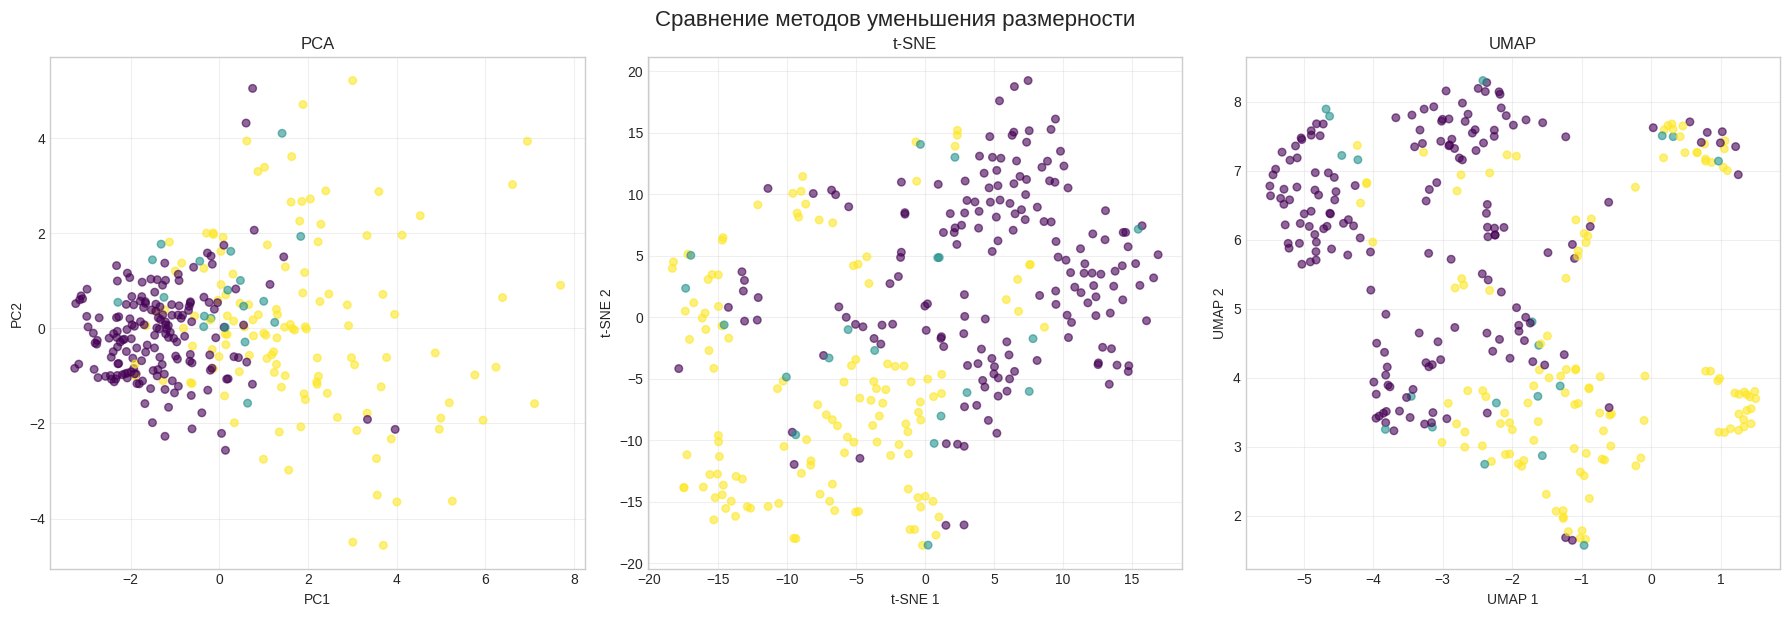


Сравнительная характеристика методов:
------------------------------------------------------------
Метод   | Сохраняет локальное | Сохраняет глобальное | Скорость | Интерпретируемость
------------------------------------------------------------
PCA     | Нет                 | Да                   | Быстро   | Высокая
t-SNE   | Да                  | Нет                  | Медленно | Низкая
UMAP    | Да                  | Частично             | Средне   | Средняя
------------------------------------------------------------


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# PCA
axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
               c=df['Status'] if 'Status' in df.columns else np.zeros(len(df)),
               cmap='viridis', alpha=0.6, s=30)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('PCA')
axes[0].grid(True, alpha=0.3)

# t-SNE
axes[1].scatter(X_tsne_final[:, 0], X_tsne_final[:, 1],
               c=df['Status'] if 'Status' in df.columns else np.zeros(len(df)),
               cmap='viridis', alpha=0.6, s=30)
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].set_title('t-SNE')
axes[1].grid(True, alpha=0.3)

# UMAP
axes[2].scatter(X_umap_final[:, 0], X_umap_final[:, 1],
               c=df['Status'] if 'Status' in df.columns else np.zeros(len(df)),
               cmap='viridis', alpha=0.6, s=30)
axes[2].set_xlabel('UMAP 1')
axes[2].set_ylabel('UMAP 2')
axes[2].set_title('UMAP')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Сравнение методов уменьшения размерности', y=1.02, fontsize=16)
plt.show()

print("\nСравнительная характеристика методов:")
print("-" * 60)
print("Метод   | Сохраняет локальное | Сохраняет глобальное | Скорость | Интерпретируемость")
print("-" * 60)
print("PCA     | Нет                 | Да                   | Быстро   | Высокая")
print("t-SNE   | Да                  | Нет                  | Медленно | Низкая")
print("UMAP    | Да                  | Частично             | Средне   | Средняя")
print("-" * 60)

# Методы кластеризации

**K-Means Clustering**

K-Means — популярный метод центроидной кластеризации. Эффективен для сферических кластеров примерно одинакового размера. Требует предварительного задания числа кластеров.

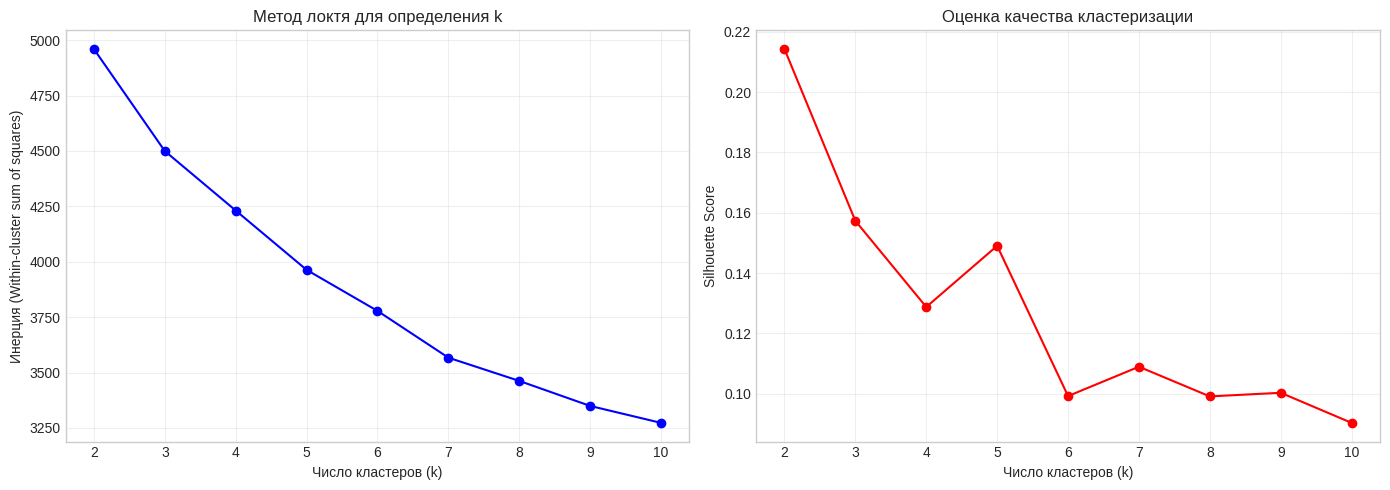

In [26]:
# Определение оптимального числа кластеров методом локтя
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, 'bo-')
axes[0].set_xlabel('Число кластеров (k)')
axes[0].set_ylabel('Инерция (Within-cluster sum of squares)')
axes[0].set_title('Метод локтя для определения k')
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_range, silhouette_scores, 'ro-')
axes[1].set_xlabel('Число кластеров (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Оценка качества кластеризации')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



Оптимальное число кластеров по Silhouette Score: 2


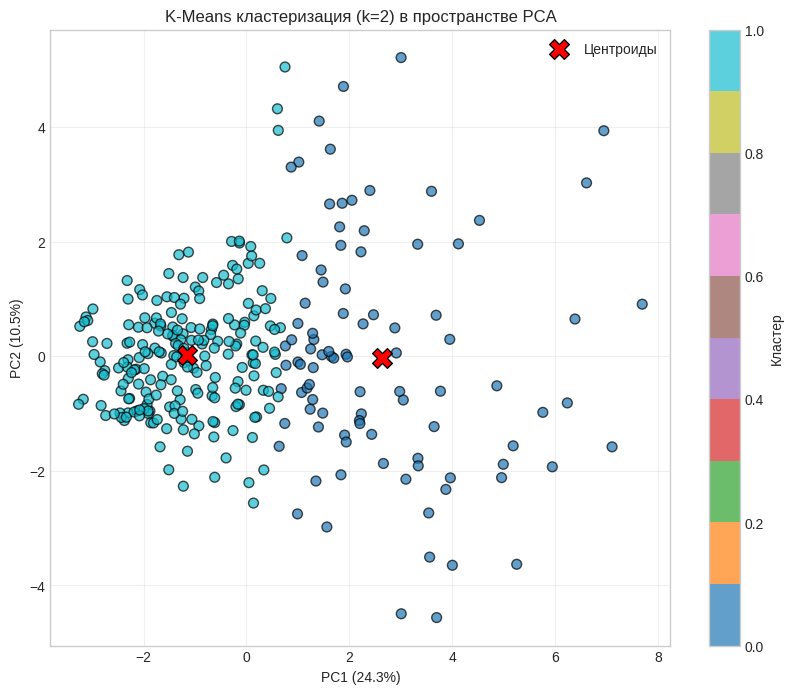


Метрики качества K-Means (k=2):
Silhouette Score: 0.214
Davies-Bouldin Index: 2.112
Calinski-Harabasz Score: 60.5


In [29]:
# Выбор оптимального k
optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"Оптимальное число кластеров по Silhouette Score: {optimal_k}")

# Применение K-Means с оптимальным k на исходных данных
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Визуализация результатов в пространстве PCA
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels,
                     cmap='tab10', alpha=0.7, s=50, edgecolors='black')

# Вычисляем центроиды в пространстве PCA
# Для этого находим среднее значение PC1 и PC2 для каждого кластера
pca_centers = np.zeros((optimal_k, 2))
for i in range(optimal_k):
    cluster_points = X_pca[kmeans_labels == i]
    pca_centers[i, 0] = np.mean(cluster_points[:, 0])  # PC1
    pca_centers[i, 1] = np.mean(cluster_points[:, 1])  # PC2

plt.scatter(pca_centers[:, 0], pca_centers[:, 1],
           c='red', s=200, marker='X',
           edgecolors='black', label='Центроиды')

plt.xlabel(f'PC1 ({explained_variance[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({explained_variance[1]*100:.1f}%)')
plt.title(f'K-Means кластеризация (k={optimal_k}) в пространстве PCA')
plt.colorbar(scatter, label='Кластер')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Метрики качества
print(f"\nМетрики качества K-Means (k={optimal_k}):")
print(f"Silhouette Score: {silhouette_score(X_scaled, kmeans_labels):.3f}")
print(f"Davies-Bouldin Index: {davies_bouldin_score(X_scaled, kmeans_labels):.3f}")
print(f"Calinski-Harabasz Score: {calinski_harabasz_score(X_scaled, kmeans_labels):.1f}")

**DBSCAN**

DBSCAN — метод кластеризации на основе плотности. Не требует задания числа кластеров, способен находить кластеры произвольной формы и выделять выбросы

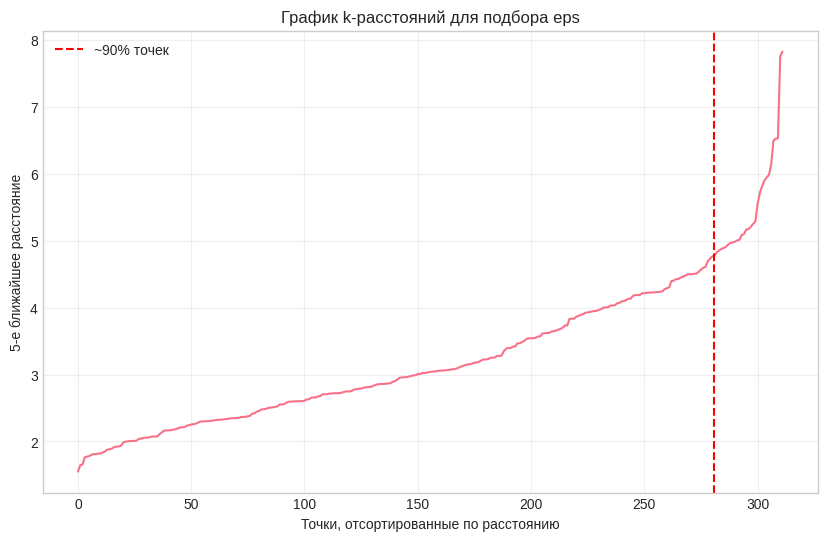

Кандидаты на eps: [3.83379378 4.20827239 4.76029536 5.16845909]
eps=0.5: кластеров=0, шумовых точек=312
eps=1.0: кластеров=0, шумовых точек=312
eps=1.5: кластеров=0, шумовых точек=312


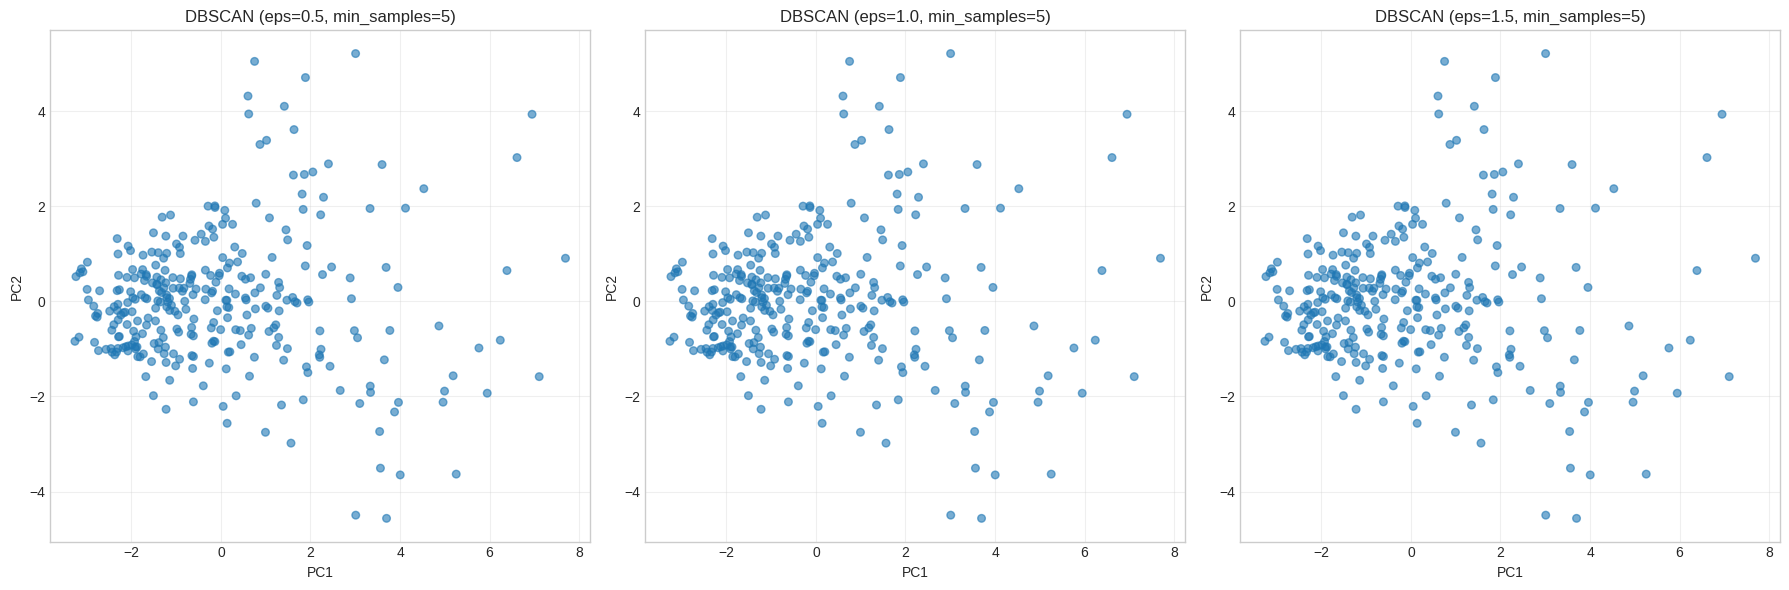

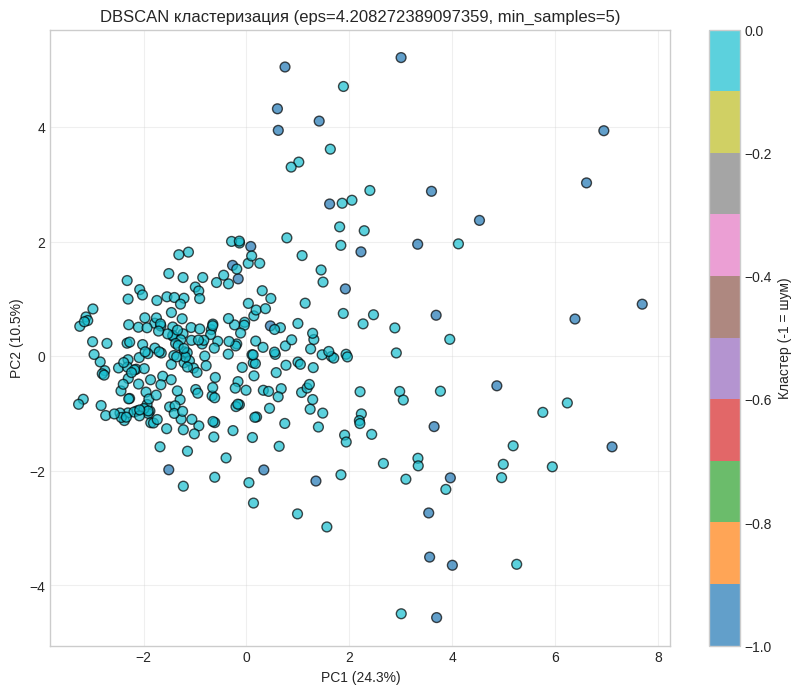

In [32]:
# Подбор параметров DBSCAN методом k-distance
from sklearn.neighbors import NearestNeighbors

min_samples = 5
knn = NearestNeighbors(n_neighbors=min_samples)
knn.fit(X_scaled)
distances, indices = knn.kneighbors(X_scaled)
distances = np.sort(distances[:, -1])

plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.xlabel('Точки, отсортированные по расстоянию')
plt.ylabel(f'{min_samples}-е ближайшее расстояние')
plt.title('График k-расстояний для подбора eps')
plt.grid(True, alpha=0.3)
plt.axvline(x=len(distances)*0.9, color='r', linestyle='--', label='~90% точек')
plt.legend()
plt.show()

# Подбор eps по "локте" на графике
eps_candidates = np.percentile(distances, [70, 80, 90, 95])
print(f"Кандидаты на eps: {eps_candidates}")

# Применение DBSCAN с разными параметрами
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
eps_values = [0.5, 1.0, 1.5]

for idx, eps in enumerate(eps_values):
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X_scaled)

    axes[idx].scatter(X_pca[:, 0], X_pca[:, 1], c=labels,
                     cmap='tab10', alpha=0.6, s=30)
    axes[idx].set_xlabel('PC1')
    axes[idx].set_ylabel('PC2')
    axes[idx].set_title(f'DBSCAN (eps={eps}, min_samples={min_samples})')
    axes[idx].grid(True, alpha=0.3)

    # Подсчёт кластеров и шума
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    print(f"eps={eps}: кластеров={n_clusters}, шумовых точек={n_noise}")

plt.tight_layout()
plt.show()

# Оптимальный DBSCAN
optimal_eps = eps_candidates[1]  # Выбираем 80-й перцентиль
dbscan = DBSCAN(eps=optimal_eps, min_samples=min_samples)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Визуализация
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels,
                     cmap='tab10', alpha=0.7, s=50, edgecolors='black')
plt.xlabel(f'PC1 ({explained_variance[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({explained_variance[1]*100:.1f}%)')
plt.title(f'DBSCAN кластеризация (eps={optimal_eps}, min_samples={min_samples})')
plt.colorbar(scatter, label='Кластер (-1 = шум)')
plt.grid(True, alpha=0.3)
plt.show()

# Метрики (исключая шумовые точки)
mask = dbscan_labels != -1
unique_labels = set(dbscan_labels[mask])
n_clusters = len(unique_labels)



Иерархическая кластеризация

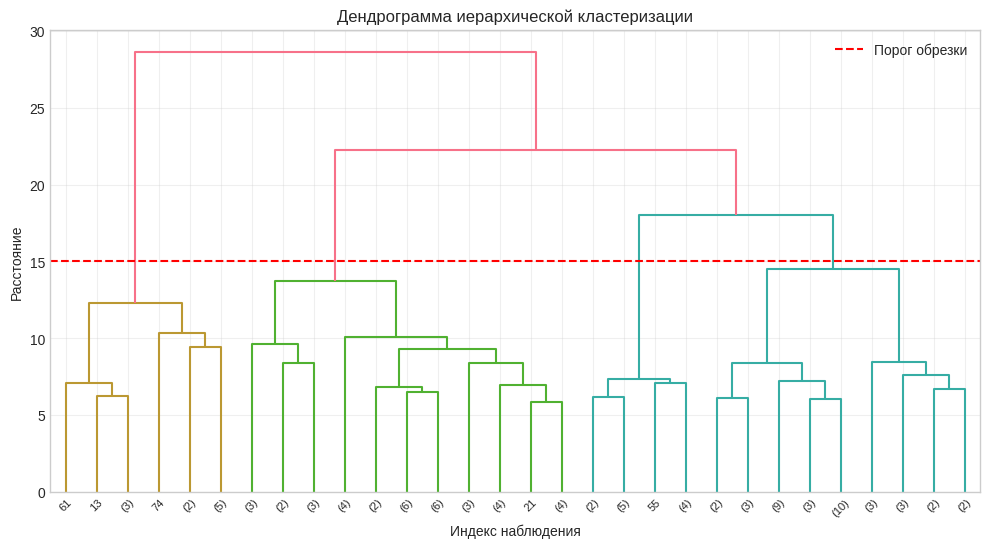

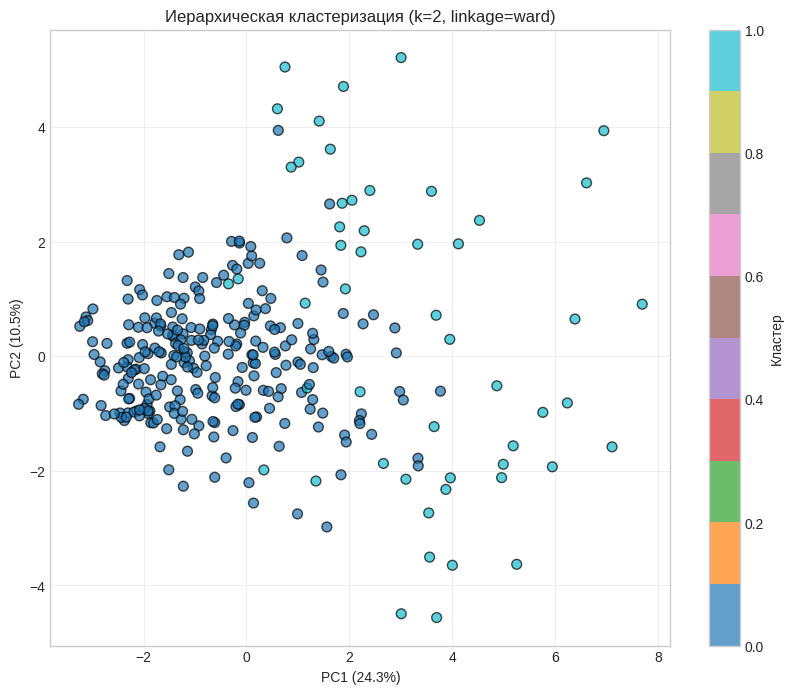


Метрики качества иерархической кластеризации:
Silhouette Score: 0.273
Davies-Bouldin Index: 2.157
Calinski-Harabasz Score: 44.8


In [33]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform

# Построение дендрограммы
linkage_matrix = linkage(X_scaled[:100], method='ward')  # Используем подвыборку для скорости

plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, truncate_mode='lastp', p=30, leaf_font_size=8)
plt.xlabel('Индекс наблюдения')
plt.ylabel('Расстояние')
plt.title('Дендрограмма иерархической кластеризации')
plt.grid(True, alpha=0.3)
plt.axhline(y=15, color='r', linestyle='--', label='Порог обрезки')
plt.legend()
plt.show()

# Применение иерархической кластеризации
hc = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
hc_labels = hc.fit_predict(X_scaled)

# Визуализация в пространстве PCA
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=hc_labels,
                     cmap='tab10', alpha=0.7, s=50, edgecolors='black')
plt.xlabel(f'PC1 ({explained_variance[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({explained_variance[1]*100:.1f}%)')
plt.title(f'Иерархическая кластеризация (k={optimal_k}, linkage=ward)')
plt.colorbar(scatter, label='Кластер')
plt.grid(True, alpha=0.3)
plt.show()

# Метрики качества
print(f"\nМетрики качества иерархической кластеризации:")
print(f"Silhouette Score: {silhouette_score(X_scaled, hc_labels):.3f}")
print(f"Davies-Bouldin Index: {davies_bouldin_score(X_scaled, hc_labels):.3f}")
print(f"Calinski-Harabasz Score: {calinski_harabasz_score(X_scaled, hc_labels):.1f}")